<a href="https://colab.research.google.com/github/Zain056/-rhombixtechnologies_task2/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the dataset
df = pd.read_csv('train.csv')

In [2]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop the Cabin column due to too many missing values
df = df.drop(columns=['Cabin'])

# Drop the 2 rows missing 'Embarked' data
df = df.dropna(subset=['Embarked'])

# Drop columns that are hard for a basic model to process without advanced engineering
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [3]:
# Convert categorical columns into numerical ones
# drop_first=True prevents multi-collinearity (e.g., if it's not female, it must be male)
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Look at the newly formatted data
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [4]:
# 'y' is the target variable (Survived)
y = df['Survived']

# 'X' is the features (everything except Survived)
X = df.drop(columns=['Survived'])

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (711, 8)
Testing data size: (178, 8)


In [5]:
# Initialize the model (max_iter is increased to ensure the math converges properly)
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


Model Accuracy: 78.09%



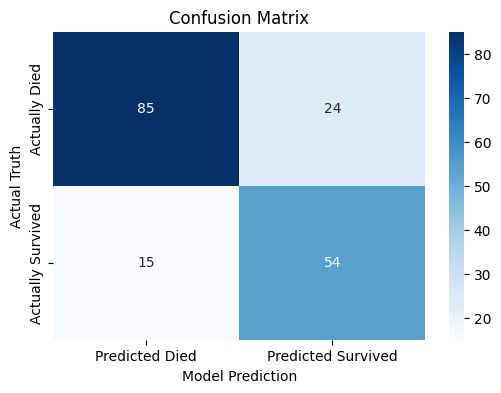

In [6]:
# Ask the model to predict survival for the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix to make it readable
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Died', 'Predicted Survived'],
            yticklabels=['Actually Died', 'Actually Survived'])
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.title('Confusion Matrix')
plt.show()

**Interpreting the Confusion Matrix:**
The confusion matrix breaks down the model's predictions into four categories:

**True Negatives (Top Left):** Passengers who actually died, and the model correctly predicted they died.

**True Positives (Bottom Right):** Passengers who actually survived, and the model correctly predicted they survived.

**False Positives (Top Right):** Passengers who actually died, but the model incorrectly predicted they survived (Type I error).

**False Negatives (Bottom Left):** Passengers who actually survived, but the model incorrectly predicted they died (Type II error).